In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.linalg import solve
from matplotlib.ticker import NullFormatter

J = np.block([[np.zeros((2,2)),np.eye(2)],[-np.eye(2),np.zeros((2,2))]])

def observations(z0,z1,delta,method):
    v = (z1-z0)/delta
    if method=="MP": x = 0.5*(z0+z1)
    elif method=="SE": x = np.concatenate([z0[:,:2],z1[:,2:]],axis=1)
    else: raise ValueError("method must be 'MP' or 'SE'")
    return x,v

def matern52_grad1(X,Y,ell):
    d = X[:,None,:]-Y[None,:,:]
    r = np.linalg.norm(d,axis=-1)
    b = np.sqrt(5.0)/ell
    a = -(b**2/3.0)*(1+b*r)*np.exp(-b*r)
    return a[...,None]*d

def matern52_hess12(X,Y,ell):
    d = X[:,None,:]-Y[None,:,:]
    r = np.linalg.norm(d,axis=-1)
    b = np.sqrt(5.0)/ell
    e = np.exp(-b*r)
    I = np.eye(X.shape[1])
    return e[...,None,None]/3.0*(b**2*(1+b*r)[...,None,None]*I
                                - b**4*d[...,:,None]*d[...,None,:])

def gram_matrix(X,ell):
    K12 = matern52_hess12(X,X,ell)
    G4 = np.einsum("ar,ijrs,bs->iajb",J,K12,J)
    M,d = X.shape
    return G4.reshape(M*d,M*d)

def fit_estimator(X,v,eta,ell):
    M,d = X.shape
    G = gram_matrix(X,ell)
    c = solve(G+M*eta*np.eye(M*d),v.reshape(-1),assume_a="pos")
    return c.reshape(M,d)

def predict_H(Z,X,c,ell):
    gradK = matern52_grad1(X,Z,ell)
    feature = np.einsum("ab,ikb->ika",J,gradK)
    return np.einsum("ika,ia->k",feature,c)

def align_constant(H_hat,H_true):
    return H_hat + np.mean(H_true-H_hat)

# def relative_hamiltonian_error(H_hat,H_true):
#     H_hat = align_constant(H_hat,H_true)
#     H_true_centered = H_true-np.mean(H_true)
#     return np.linalg.norm(H_hat-H_true)/np.linalg.norm(H_true_centered)
def relative_hamiltonian_error(H_hat,H_true):
    H_hat = align_constant(H_hat,H_true)
    return np.linalg.norm(H_hat-H_true)/np.linalg.norm(H_true)

def fitted_slope(x,y):
    return np.polyfit(np.log(x),np.log(y),1)[0]

def make_test_slice(q_min,q_max,n_grid,p_slice):
    q1 = np.linspace(q_min,q_max,n_grid)
    q2 = np.linspace(q_min,q_max,n_grid)
    Q1,Q2 = np.meshgrid(q1,q2)
    Z = np.column_stack([Q1.ravel(),Q2.ravel(),
                         np.full(Q1.size,p_slice[0]),
                         np.full(Q1.size,p_slice[1])])
    return Q1,Q2,Z

def exact_flow(z0,delta,XH_fun):
    sol = solve_ivp(lambda t,z:XH_fun(z),(0.0,delta),z0,method="DOP853",
                    rtol=1e-12,atol=1e-14,t_eval=[delta])
    if not sol.success: raise RuntimeError(sol.message)
    return sol.y[:,-1]

def sample_initial_conditions(N,rng,q_box,p_box,H_fun,E_max=None):
    samples = []
    while len(samples)<N:
        q = rng.uniform(-q_box,q_box,2)
        p = rng.uniform(-p_box,p_box,2)
        z = np.concatenate([q,p])
        if E_max is None or H_fun(z)<=E_max: samples.append(z)
    return np.asarray(samples)

def generate_flow_data(z0,deltas,XH_fun):
    return {delta:np.array([exact_flow(z,delta,XH_fun) for z in z0]) for delta in deltas}

# ============================================================
# Common reconstruction plot
# ============================================================
def plot_reconstruction(Q1,Q2,H_true,H_hat,title,filename):
    H_hat = align_constant(H_hat,H_true)
    H_true = H_true.reshape(Q1.shape)
    H_hat = H_hat.reshape(Q1.shape)
    error = np.abs(H_hat-H_true)

    fig = plt.figure(figsize=(12,3.8))
    ax1 = fig.add_subplot(131,projection="3d")
    ax2 = fig.add_subplot(132,projection="3d")
    ax3 = fig.add_subplot(133)

    zmin = min(H_true.min(),H_hat.min())
    zmax = max(H_true.max(),H_hat.max())

    ax1.plot_surface(Q1,Q2,H_true,cmap="winter",linewidth=0,antialiased=True)
    ax2.plot_surface(Q1,Q2,H_hat,cmap="winter",linewidth=0,antialiased=True)
    im = ax3.imshow(error,origin="lower",extent=[Q1.min(),Q1.max(),Q2.min(),Q2.max()],
                    aspect="equal",cmap="jet")

    for a in [ax1,ax2]:
        a.set_xlabel(r"$q_1$")
        a.set_ylabel(r"$q_2$")
        a.set_zlabel(r"$H$")
        a.set_zlim(zmin,zmax)
        a.view_init(elev=25,azim=-60)

    ax1.set_title("Ground truth")
    ax2.set_title("Learned Hamiltonian")
    ax3.set_title("Mismatch error")
    ax3.set_xlabel(r"$q_1$")
    ax3.set_ylabel(r"$q_2$")

    fig.colorbar(im,ax=ax3,fraction=0.046,pad=0.04)
    fig.suptitle(title,y=0.98)

    plt.tight_layout()
    os.makedirs("fig",exist_ok=True)
    plt.savefig(f"fig/{filename}.pdf",bbox_inches="tight")
    plt.savefig(f"fig/{filename}.png",dpi=300,bbox_inches="tight")
    plt.show()

Double pendulum relative error = 1.5521e-02
Vertical shift = 1.6755e+01


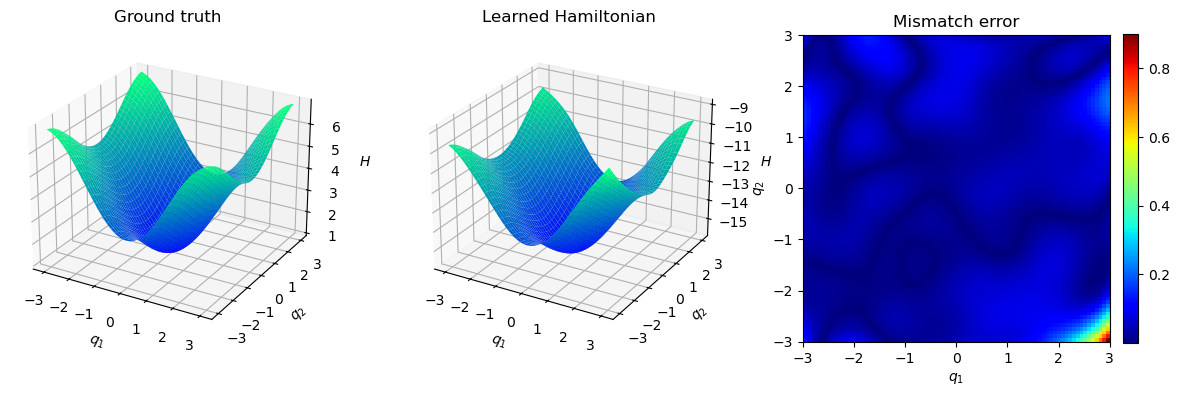

In [9]:
# ============================================================
# Main 1: Double pendulum
# ============================================================

# Hamiltonian
def H_DP(z):
    q1,q2,p1,p2 = np.moveaxis(np.asarray(z),-1,0)
    d = q1-q2
    D = 1.0+np.sin(d)**2
    T = 0.5*(p1**2+2*p2**2-2*p1*p2*np.cos(d))/D
    V = 4.0-2.0*np.cos(q1)-np.cos(q2)
    return T+V

def XH_DP(z):
    q1,q2,p1,p2 = z
    d = q1-q2
    s,c = np.sin(d),np.cos(d)
    D = 1.0+s**2
    A = p1**2+2*p2**2-2*p1*p2*c
    dT = s*(p1*p2*D-c*A)/(D**2)

    dq1 = (p1-p2*c)/D
    dq2 = (2*p2-p1*c)/D
    dp1 = -(dT+2*np.sin(q1))
    dp2 = dT-np.sin(q2)
    return np.array([dq1,dq2,dp1,dp2])

# parameters
seed = 1234
N = 1000
delta = 0.10
eta = 1e-9
ell = 3.0

q_box = 3.0
p_box = 3.0
p_slice = np.array([0.0,0.0])

q_min,q_max = -3.0,3.0
n_grid = 81

# data
rng = np.random.default_rng(seed)
z0 = sample_initial_conditions(N,rng,q_box,p_box,H_DP,E_max=None)
z1 = np.array([exact_flow(z,delta,XH_DP) for z in z0])

X,v = observations(z0,z1,delta,"MP")
c = fit_estimator(X,v,eta,ell)

# test slice
Q1,Q2,Z_test = make_test_slice(q_min,q_max,n_grid,p_slice)
H_true = H_DP(Z_test)
H_hat = predict_H(Z_test,X,c,ell)

# error only: align additive constant
H_hat_aligned = align_constant(H_hat,H_true)
error = np.abs(H_hat_aligned-H_true)
rel_error = relative_hamiltonian_error(H_hat,H_true)

print(f"Double pendulum relative error = {rel_error:.4e}")
print(f"Vertical shift = {np.mean(H_true-H_hat):.4e}")

# plot
H_true_plot = H_true.reshape(Q1.shape)
H_hat_plot = H_hat.reshape(Q1.shape)
error_plot = error.reshape(Q1.shape)

fig = plt.figure(figsize=(12,3.8))
ax1 = fig.add_subplot(131,projection="3d")
ax2 = fig.add_subplot(132,projection="3d")
ax3 = fig.add_subplot(133)

ax1.plot_surface(Q1,Q2,H_true_plot,cmap="winter",linewidth=0,antialiased=True)
ax2.plot_surface(Q1,Q2,H_hat_plot,cmap="winter",linewidth=0,antialiased=True)
im = ax3.imshow(error_plot,origin="lower",extent=[q_min,q_max,q_min,q_max],
                aspect="equal",cmap="jet")

for a in [ax1,ax2]:
    a.set_xlabel(r"$q_1$")
    a.set_ylabel(r"$q_2$")
    a.set_zlabel(r"$H$")
    a.view_init(elev=25,azim=-60)

ax1.set_title("Ground truth")
ax2.set_title("Learned Hamiltonian")
ax3.set_title("Mismatch error")
ax3.set_xlabel(r"$q_1$")
ax3.set_ylabel(r"$q_2$")

fig.colorbar(im,ax=ax3,fraction=0.046,pad=0.04)
plt.tight_layout()

os.makedirs("fig",exist_ok=True)
plt.savefig("fig/DoublePendulum_reconstruction.pdf",bbox_inches="tight")
plt.savefig("fig/DoublePendulum_reconstruction.png",dpi=300,bbox_inches="tight")
plt.show()

Frenkel-Kontorova relative error = 5.5799e-03
Vertical shift = 8.1458e-01


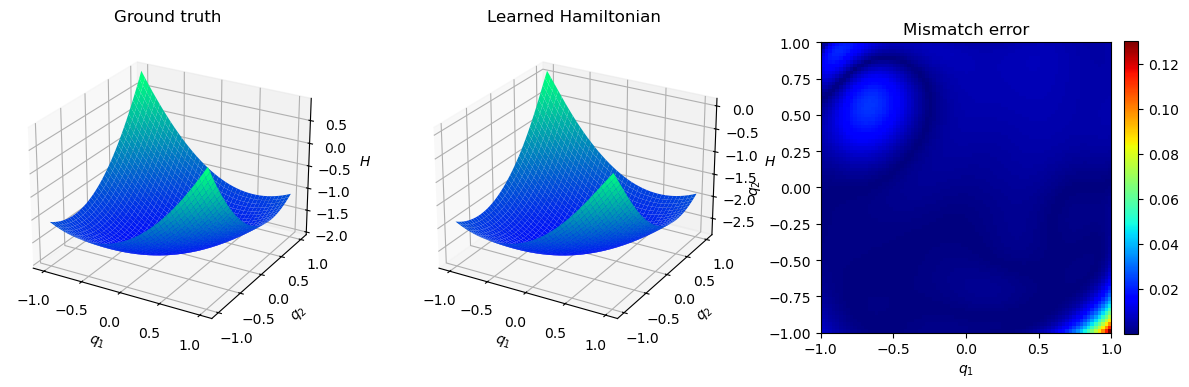

In [10]:
# ============================================================
# Main 2: Frenkel--Kontorova model
# ============================================================

# Hamiltonian
g_fk = 1.0

def H_FK(z):
    q,p = z[...,:2],z[...,2:]
    q1,q2 = q[...,0],q[...,1]
    return 0.5*np.sum(p**2,axis=-1)-np.cos(q1)-np.cos(q2)+0.5*g_fk*(q2-q1)**2

def XH_FK(z):
    q1,q2,p1,p2 = z
    dq1,dq2 = p1,p2
    dp1 = -np.sin(q1)+g_fk*(q2-q1)
    dp2 = -np.sin(q2)-g_fk*(q2-q1)
    return np.array([dq1,dq2,dp1,dp2])

# parameters
seed = 1234
N = 200
delta = 0.10
eta = 1e-9
ell = 1.0

q_box = 1.0
p_box = 1.0
p_slice = np.array([0.0,0.0])

q_min,q_max = -1.0,1.0
n_grid = 81

# data
rng = np.random.default_rng(seed)
z0 = sample_initial_conditions(N,rng,q_box,p_box,H_FK,E_max=None)
z1 = np.array([exact_flow(z,delta,XH_FK) for z in z0])

X,v = observations(z0,z1,delta,"MP")
c = fit_estimator(X,v,eta,ell)

# test slice
Q1,Q2,Z_test = make_test_slice(q_min,q_max,n_grid,p_slice)
H_true = H_FK(Z_test)
H_hat = predict_H(Z_test,X,c,ell)

# error only: align additive constant
H_hat_aligned = align_constant(H_hat,H_true)
error = np.abs(H_hat_aligned-H_true)
rel_error = relative_hamiltonian_error(H_hat,H_true)

print(f"Frenkel-Kontorova relative error = {rel_error:.4e}")
print(f"Vertical shift = {np.mean(H_true-H_hat):.4e}")

# plot
H_true_plot = H_true.reshape(Q1.shape)
H_hat_plot = H_hat.reshape(Q1.shape)
error_plot = error.reshape(Q1.shape)

fig = plt.figure(figsize=(12,3.8))
ax1 = fig.add_subplot(131,projection="3d")
ax2 = fig.add_subplot(132,projection="3d")
ax3 = fig.add_subplot(133)

ax1.plot_surface(Q1,Q2,H_true_plot,cmap="winter",linewidth=0,antialiased=True)
ax2.plot_surface(Q1,Q2,H_hat_plot,cmap="winter",linewidth=0,antialiased=True)
im = ax3.imshow(error_plot,origin="lower",extent=[q_min,q_max,q_min,q_max],
                aspect="equal",cmap="jet")

for a in [ax1,ax2]:
    a.set_xlabel(r"$q_1$")
    a.set_ylabel(r"$q_2$")
    a.set_zlabel(r"$H$")
    a.view_init(elev=25,azim=-60)

ax1.set_title("Ground truth")
ax2.set_title("Learned Hamiltonian")
ax3.set_title("Mismatch error")
ax3.set_xlabel(r"$q_1$")
ax3.set_ylabel(r"$q_2$")

fig.colorbar(im,ax=ax3,fraction=0.046,pad=0.04)
plt.tight_layout()

os.makedirs("fig",exist_ok=True)
plt.savefig("fig/FK_reconstruction.pdf",bbox_inches="tight")
plt.savefig("fig/FK_reconstruction.png",dpi=300,bbox_inches="tight")
plt.show()

/var/folders/pr/y5w4hs8n4kl0v1ph645fl2ch0000gn/T/ipykernel_25370/2523345069.py:11: RuntimeWarning: invalid value encountered in divide
  sinc = np.where(r>1e-10,np.sin(r)/r,1.0)


Highly non-convex relative error = 7.2964e-02
Vertical shift = 5.4817e+00


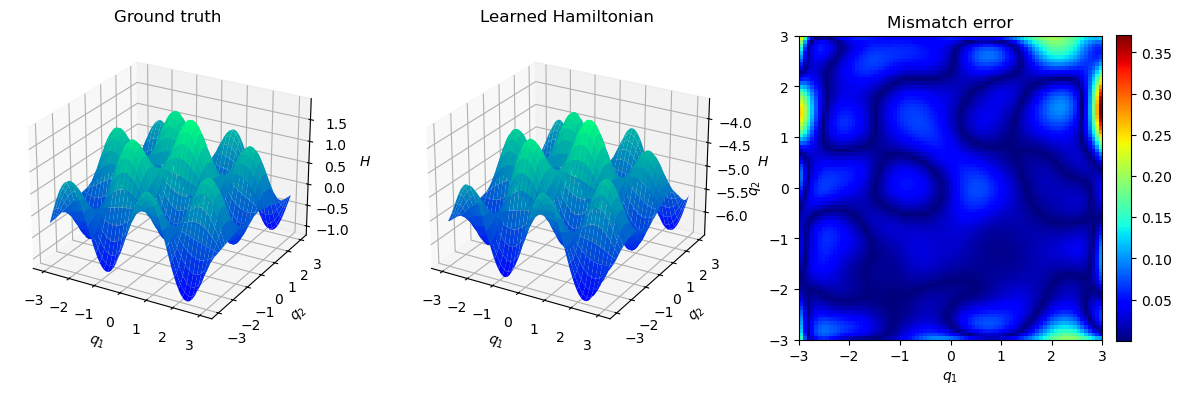

In [11]:
# ============================================================
# Main 3: Highly non-convex potential
# ============================================================

# Hamiltonian
a_nc = 2*np.pi/3

def V_NC(q):
    q1,q2 = q[...,0],q[...,1]
    r = np.sqrt(q1**2+q2**2)
    sinc = np.where(r>1e-10,np.sin(r)/r,1.0)
    return np.sin(a_nc*q1)*np.cos(a_nc*q2)+sinc

def gradV_NC(q):
    q1,q2 = q[...,0],q[...,1]
    r = np.sqrt(q1**2+q2**2)
    coef = np.where(r>1e-8,(r*np.cos(r)-np.sin(r))/r**3,-1/3)
    g1 = a_nc*np.cos(a_nc*q1)*np.cos(a_nc*q2)+coef*q1
    g2 = -a_nc*np.sin(a_nc*q1)*np.sin(a_nc*q2)+coef*q2
    return np.stack([g1,g2],axis=-1)

def H_NC(z):
    q,p = z[...,:2],z[...,2:]
    return 0.5*np.sum(p**2,axis=-1)+V_NC(q)

def XH_NC(z):
    q,p = z[:2],z[2:]
    return np.concatenate([p,-gradV_NC(q)])

# parameters
seed = 1234
N = 1500
delta = 0.05
eta = 1e-9
ell = 1.2

q_box = 3.0
p_box = 3.0
p_slice = np.array([0.0,0.0])
q_min,q_max = -3.0,3.0
n_grid = 81

# data
rng = np.random.default_rng(seed)
z0 = sample_initial_conditions(N,rng,q_box,p_box,H_NC,E_max=None)
z1 = np.array([exact_flow(z,delta,XH_NC) for z in z0])

X,v = observations(z0,z1,delta,"MP")
c = fit_estimator(X,v,eta,ell)

# test slice
Q1,Q2,Z_test = make_test_slice(q_min,q_max,n_grid,p_slice)
H_true = H_NC(Z_test)
H_hat = predict_H(Z_test,X,c,ell)

# error only: align additive constant
H_hat_aligned = align_constant(H_hat,H_true)
error = np.abs(H_hat_aligned-H_true)
rel_error = relative_hamiltonian_error(H_hat,H_true)

print(f"Highly non-convex relative error = {rel_error:.4e}")
print(f"Vertical shift = {np.mean(H_true-H_hat):.4e}")

# plot
H_true_plot = H_true.reshape(Q1.shape)
H_hat_plot = H_hat.reshape(Q1.shape)
error_plot = error.reshape(Q1.shape)

fig = plt.figure(figsize=(12,3.8))
ax1 = fig.add_subplot(131,projection="3d")
ax2 = fig.add_subplot(132,projection="3d")
ax3 = fig.add_subplot(133)

ax1.plot_surface(Q1,Q2,H_true_plot,cmap="winter",linewidth=0,antialiased=True)
ax2.plot_surface(Q1,Q2,H_hat_plot,cmap="winter",linewidth=0,antialiased=True)
im = ax3.imshow(error_plot,origin="lower",extent=[q_min,q_max,q_min,q_max],
                aspect="equal",cmap="jet")

for a in [ax1,ax2]:
    a.set_xlabel(r"$q_1$")
    a.set_ylabel(r"$q_2$")
    a.set_zlabel(r"$H$")
    a.view_init(elev=25,azim=-60)

ax1.set_title("Ground truth")
ax2.set_title("Learned Hamiltonian")
ax3.set_title("Mismatch error")
ax3.set_xlabel(r"$q_1$")
ax3.set_ylabel(r"$q_2$")

fig.colorbar(im,ax=ax3,fraction=0.046,pad=0.04)
plt.tight_layout()

os.makedirs("fig",exist_ok=True)
plt.savefig("fig/Nonconvex_reconstruction.pdf",bbox_inches="tight")
plt.savefig("fig/Nonconvex_reconstruction.png",dpi=300,bbox_inches="tight")
plt.show()